In [1]:
import matplotlib.pyplot as plt

from phoxipy import PhoXiSensor

p = PhoXiSensor("1703005")
p.start()

frame = p.read()
# plt.title("Intensity Image")
# plt.imshow(frame.color.data)
# plt.tight_layout()
# plt.show()
# plt.imsave("intensity_image.png", frame.color.data)
p.stop()
import PIL.Image as Image
import numpy as np
from decluttering.data.utils.detic_dataloader import DeticDataloader
import matplotlib.pyplot as plt

detic = DeticDataloader()
detic.create()
detic.default_vocab()

/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


Inference time:  1.3405282497406006


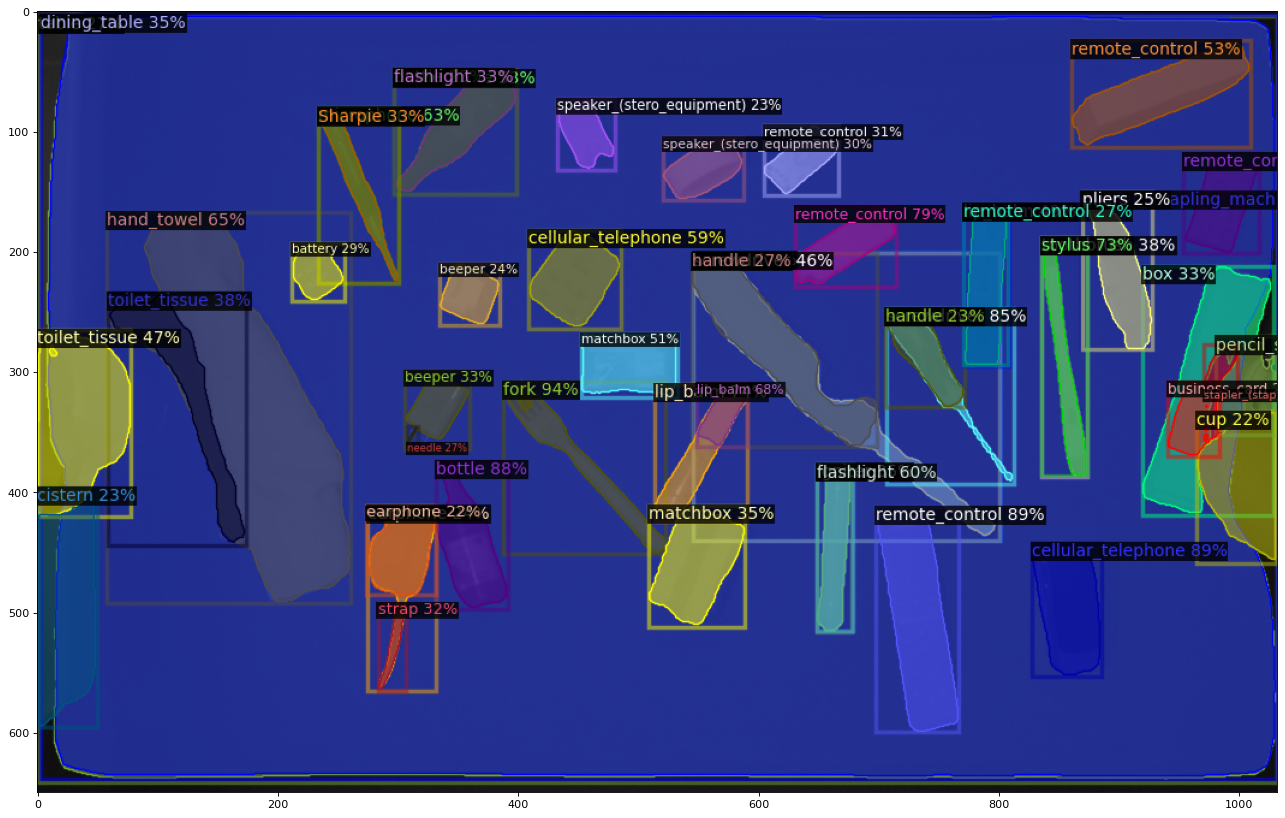

In [2]:

# im_frame1 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/intensity_image.png')
# im_frame1 = im_frame1.resize((640, 480))
im_frame1 = frame.color.data
np_frame1 = np.array(im_frame1)

# remove alpha channel
np_frame1 = np_frame1[0:650, :, :3]

out = detic.predict(np_frame1)
output_im = out['vis'].get_image()
# print(output_im.shape)
plt.figure(figsize=(20, 18), dpi=80)
plt.imshow(output_im)
